### 5.4 中心極限定理のデモ
正規分布はこれまで、２項分布の近似として得られることが分かったが、真の有用性はそれにとどまらず、しばしばより一般的な分布に対しても正規分布が成立することにある。**n回の試行を多数回繰り返すとき**、n回の試行の平均値が多数回分得られるが、その**平均値の分布**は、元の分布が正規分布でなくとも、正規分布に従う（中心極限定理）

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from numpy.random import normal
from scipy.stats import norm
import random, japanize_matplotlib

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

1 :  2 回  出現確率:  0.2
2 :  2 回  出現確率:  0.2
3 :  2 回  出現確率:  0.2
4 :  1 回  出現確率:  0.1
5 :  2 回  出現確率:  0.2
6 :  1 回  出現確率:  0.1


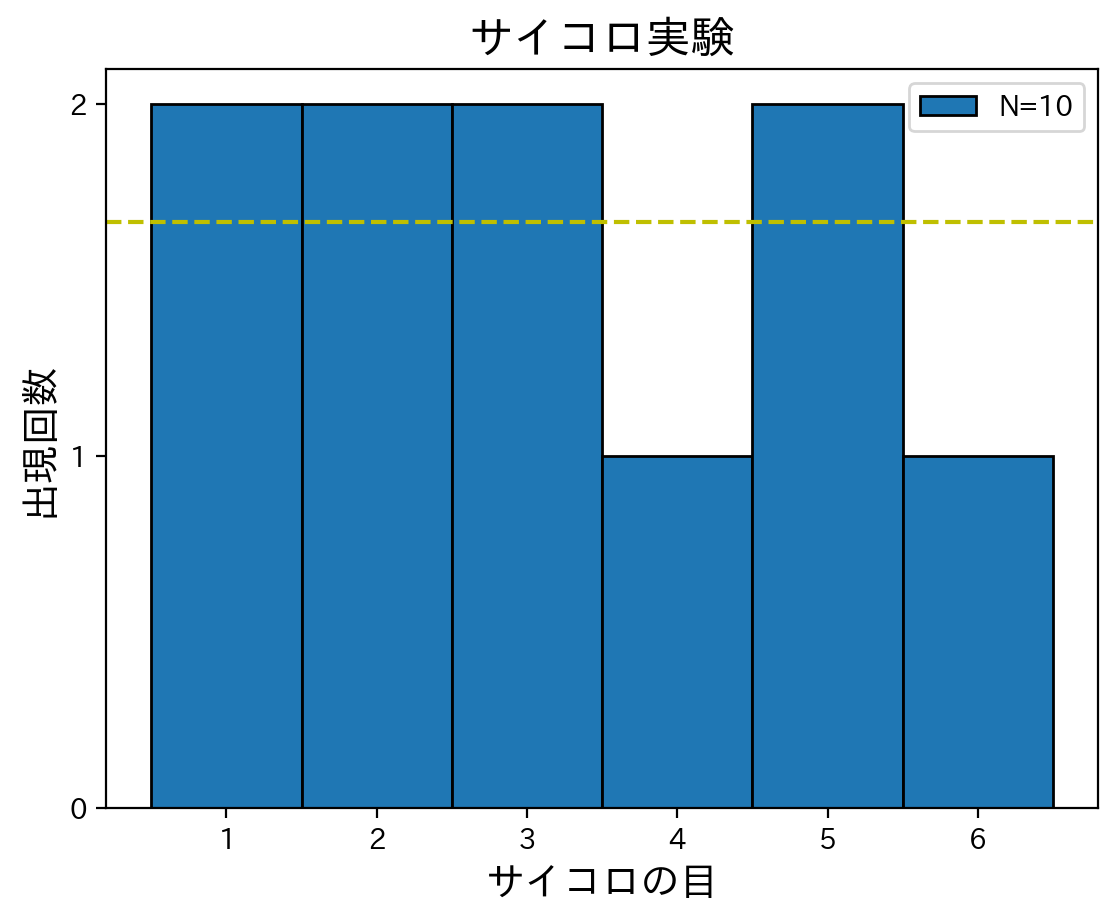

In [2]:
from numpy.random import randint
import pprint

dice = [1,2,3,4,5,6]

# サイコロを N 回振り、各出目の数をカウントする
N = 10

# サイコロの出た目（試行結果）の表示
result = randint(1, 7 ,N).tolist()
#pprint.pprint(result, compact=True)

# サイコロの各目の出現確率を可視化
for k in dice:
    print(k,': ', result.count(k), '回  出現確率: ', result.count(k)/len(result))
    
plt.hist(result, bins=range(1,8), ec='k', align='left',density=False, label=f"N={N}") # densityは全体を1に規格化

# 縦軸目盛を整数に制限
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.xticks(dice)
plt.title("サイコロ実験", fontsize=16)
plt.xlabel("サイコロの目", fontsize=14)
plt.ylabel("出現回数", fontsize=14)

plt.legend()
plt.axhline(y=N/6, c='y', ls='--');
#plt.axhline(y=np.mean(result), c='r', ls='-');

In [3]:
# 実験条件設定

sample_mean=[]
dice = np.array(range(1,7))

for k in range(1000):
    sample = np.random.choice(dice,N)
    s_ave = np.mean(sample)
    s_var = np.var(sample, ddof=0)   # ddof=0: 標本分散（nで割る）
    U_var = np.var(sample, ddof=1)   # ddof=1: 不偏分散（n-1で割る）
    if k < 20:
        print(f"標本:{k+1:>2} {sample}  標本平均: {s_ave:6.3f}")
    sample_mean.append(s_ave)

標本: 1 [2 1 4 1 3 5 6 6 6 3]  標本平均:  3.700
標本: 2 [5 5 5 2 1 2 6 3 1 4]  標本平均:  3.400
標本: 3 [6 5 4 2 6 4 3 4 5 3]  標本平均:  4.200
標本: 4 [4 6 6 5 2 6 1 2 2 3]  標本平均:  3.700
標本: 5 [2 3 2 3 1 5 1 3 4 6]  標本平均:  3.000
標本: 6 [1 1 1 2 1 4 3 1 5 1]  標本平均:  2.000
標本: 7 [6 1 5 1 3 2 1 6 3 3]  標本平均:  3.100
標本: 8 [3 3 6 3 6 5 3 1 6 1]  標本平均:  3.700
標本: 9 [4 5 1 3 2 4 4 4 4 2]  標本平均:  3.300
標本:10 [4 4 6 6 6 1 5 6 3 1]  標本平均:  4.200
標本:11 [5 2 4 3 3 2 2 4 1 3]  標本平均:  2.900
標本:12 [1 2 5 4 2 3 6 1 4 3]  標本平均:  3.100
標本:13 [2 1 2 5 3 3 2 3 2 5]  標本平均:  2.800
標本:14 [5 4 5 4 3 6 3 2 3 6]  標本平均:  4.100
標本:15 [3 1 6 2 2 6 2 5 3 3]  標本平均:  3.300
標本:16 [6 2 5 5 1 4 6 3 5 2]  標本平均:  3.900
標本:17 [3 2 4 3 6 2 1 1 2 2]  標本平均:  2.600
標本:18 [4 2 5 2 5 4 4 5 4 3]  標本平均:  3.800
標本:19 [3 3 2 5 3 5 4 6 3 6]  標本平均:  4.000
標本:20 [1 3 1 5 6 5 4 5 6 1]  標本平均:  3.700


標準偏差 0.45643546458763845


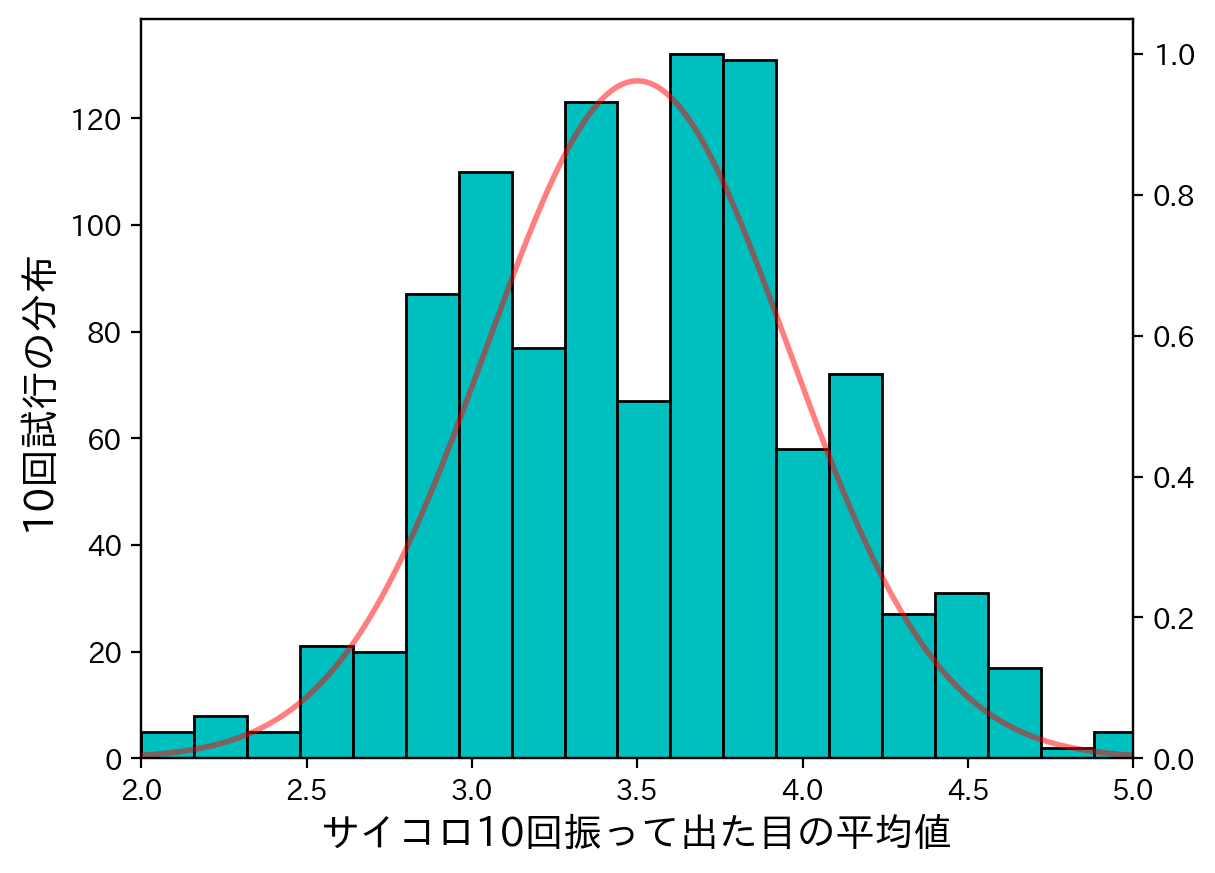

In [4]:
# ヒストグラムの表示
bins = 20
plt.xlabel(f'サイコロ{N}回振って出た目の平均値', fontsize=14)
plt.ylabel(f'{N}回試行の分布', fontsize=14)

# ヒストグラムの表示
plt.xlabel(f'サイコロ{N}回振って出た目の平均値', fontsize=14)
plt.ylabel(f'{N}回試行の分布', fontsize=14);
plt.hist(sample_mean, bins=bins, facecolor='c', ec='k')

# 理論値の表示
# loc=平均値、scale=標準偏差を指定している
# [a,b]の一様分布の平均と分散が、それぞれ(a+b)/2, (b-a)^2/12であることを利用(a=1, b=6)
plt.twinx()
a=1; b=6
myu = (a+b)/2
sigma = np.sqrt((b-a)*(b-a)/12)/np.sqrt(N)
print("標準偏差", sigma)
x = np.linspace(2, 6, 2**10)
curve = norm.pdf(x, loc=myu, scale=sigma)

plt.plot(x, curve*1.1,lw=2, color="r", alpha=0.5)
plt.axis([2, 5, 0, np.max(curve)*1.2]);  #[X軸最小値, X軸最大値, Y軸最小値, Y軸最大値]
plt.xlim(2,5);